In [5]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames
using CSV

In [6]:
using Revise
using Newtrinos


In [19]:
# NNATURALNESS

using Revise
using Newtrinos

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:IO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   gerda= Newtrinos.gerda.configure(physics),
);

par= Newtrinos.get_params(experiments)

#matrix=Newtrinos.osc.get_matrices(osc_cfg.flavour)(par)
#display(osc_cfg.flavour)

[ Info: Loading Gerda data


(N = 100.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = -0.0024, δCP = 1.0, η = 1.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

Check of the Majorana effective mass

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


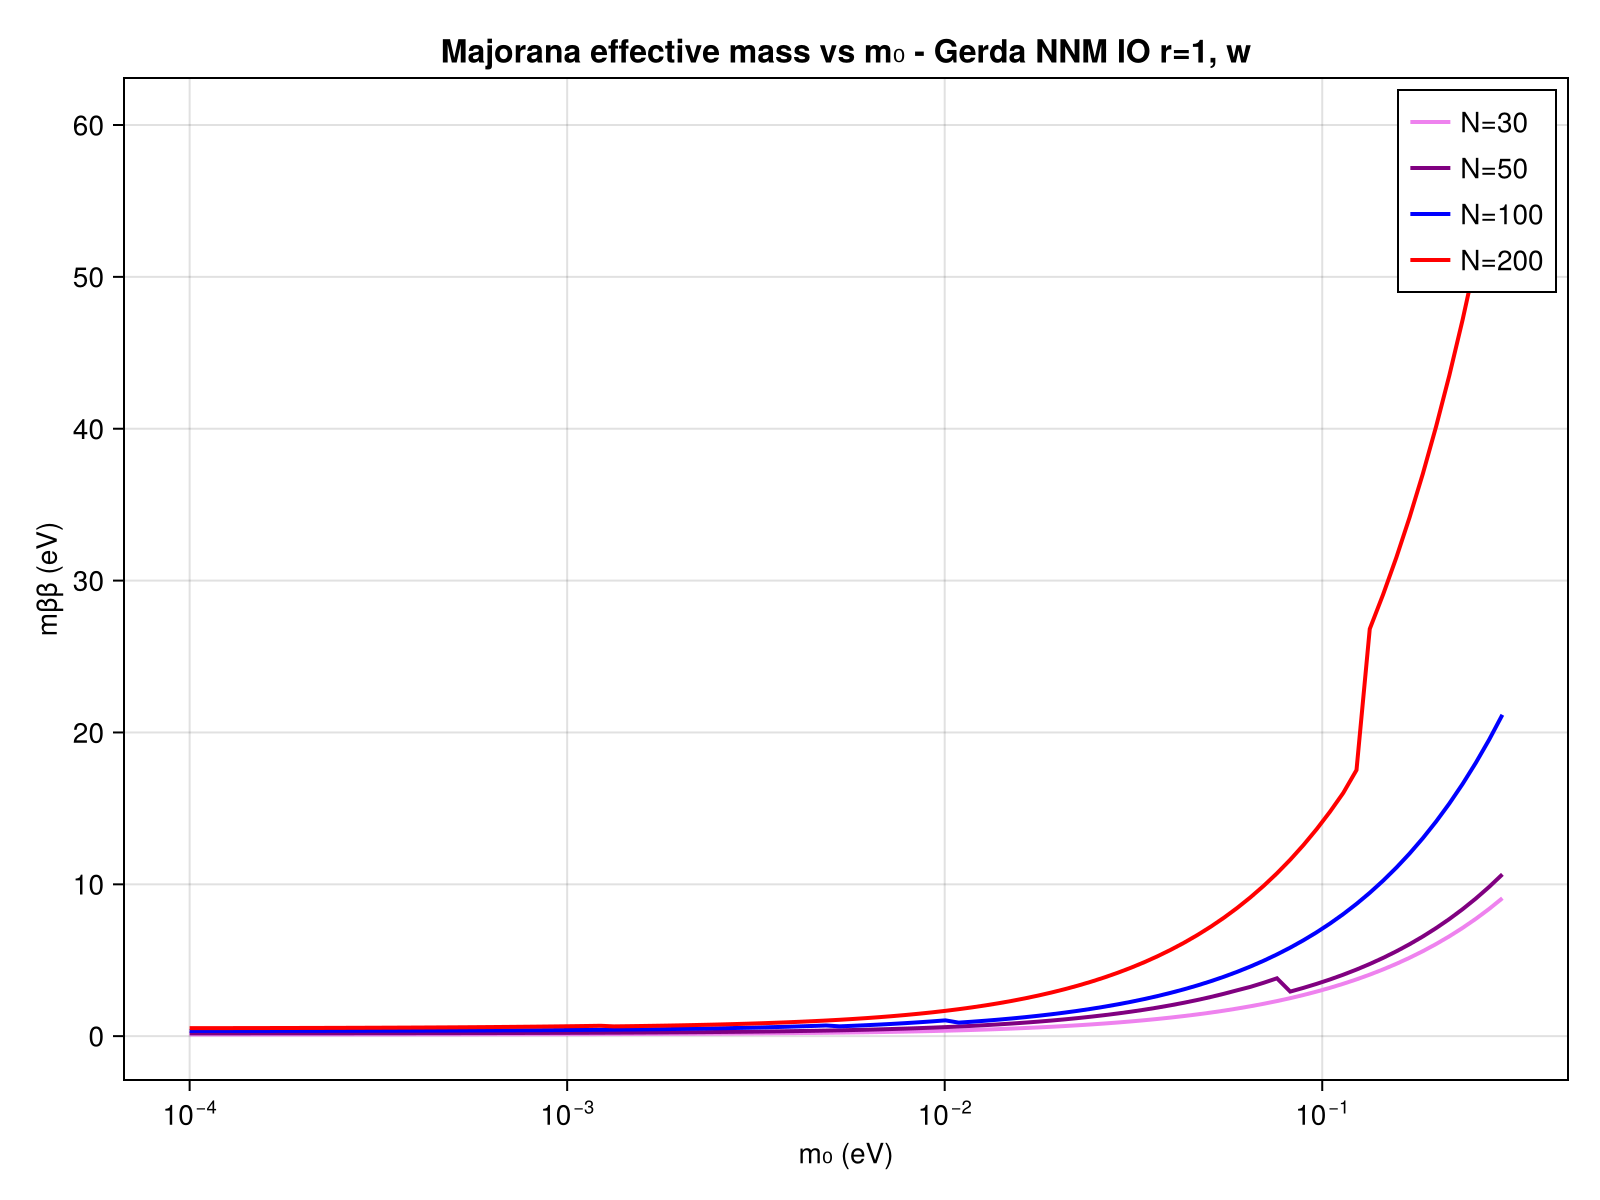

In [13]:
using CairoMakie

m0_range= logrange(1e-4, 0.3, 100)

mass_nu_0=[]
mass_nu_1=[]
mass_nu_2=[]
mass_nu_3=[]

for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=30))   
    mass = Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_0, mass)
    
end    

for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=50))   
    mass = Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_1, mass)
    
end    

for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=100))   
    mass = Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_2, mass)
    
end    


for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=200))   
    mass = Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_3, mass)
    
end    


# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
   xlabel = "m₀ (eV)",
   ylabel = "mββ (eV)",
    title = "Majorana effective mass vs m₀ - Gerda NNM IO r=1, w",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14, 
    xscale = log10
)


# Plot the main curve
lines!(ax, m0_range, mass_nu_0,
    color = :violet,
    linewidth = 2,
    label = "N=30"
)


# Plot the main curve
lines!(ax, m0_range, mass_nu_1,
    color = :purple,
    linewidth = 2,
    label = "N=50"
)

lines!(ax, m0_range, mass_nu_2,
    color = :blue,
    linewidth = 2,
    label = "N=100"
)

lines!(ax, m0_range, mass_nu_3,
    color = :red,
    linewidth = 2,
    label = "N=200"
)

axislegend(ax, position = :rt) 
#save("/home/sofialon/Newtrinos.jl/plots_NP/gerda_checks_new_pert/mbb_m0_NNM_NO_w.png", fig)


display("image/png", fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


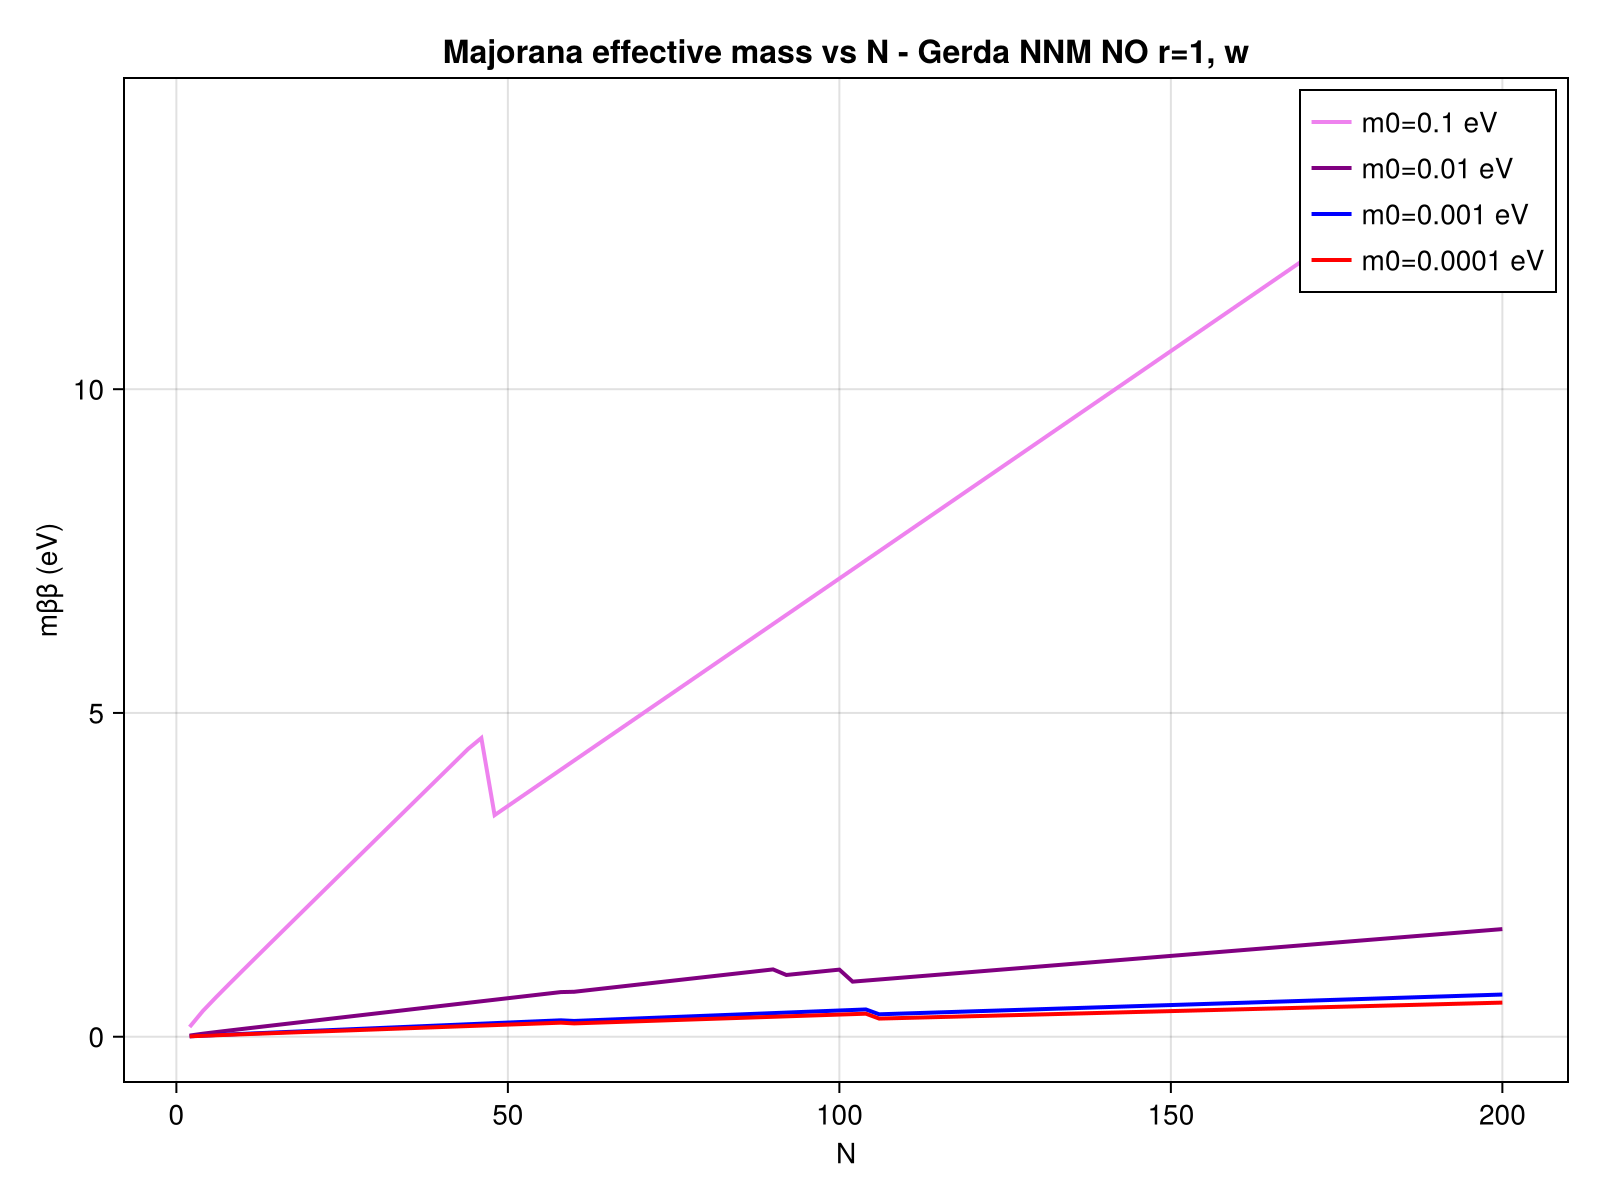

In [14]:

N_range= range(2,200, 100)

mass_nu_0=[]
mass_nu_1=[]
mass_nu_2=[]
mass_nu_3=[]

for n in N_range

    par_p= merge(par, (m₀=0.1, r=1, N=n))   
    mass = Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_0, mass)
    
end    

for n in N_range

    par_p= merge(par, (m₀=0.01, r=1, N=n))   
    mass = Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_1, mass)
    
end    

for n in N_range

    par_p= merge(par, (m₀=0.001, r=1, N=n))   
    mass = Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_2, mass)
    
end    


for n in N_range

    par_p= merge(par, (m₀=0.0001, r=1, N=n))   
    mass = Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_3, mass)
    
end    


# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
   xlabel = "N",
   ylabel = "mββ (eV)",
    title = "Majorana effective mass vs N - Gerda NNM NO r=1, w",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14, 
    #xscale = log10
)


# Plot the main curve
lines!(ax, N_range, mass_nu_0,
    color = :violet,
    linewidth = 2,
    label = "m0=0.1 eV"
)


# Plot the main curve
lines!(ax, N_range, mass_nu_1,
    color = :purple,
    linewidth = 2,
    label = "m0=0.01 eV"
)

lines!(ax, N_range, mass_nu_2,
    color = :blue,
    linewidth = 2,
    label = "m0=0.001 eV"
)

lines!(ax, N_range, mass_nu_3,
    color = :red,
    linewidth = 2,
    label = "m0=0.0001 eV"
)

axislegend(ax, position = :rt) 
#save("/home/sofialon/Newtrinos.jl/plots_NP/gerda_checks_new_pert/mbb_N_NNM_NO_w.png", fig)


display("image/png", fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


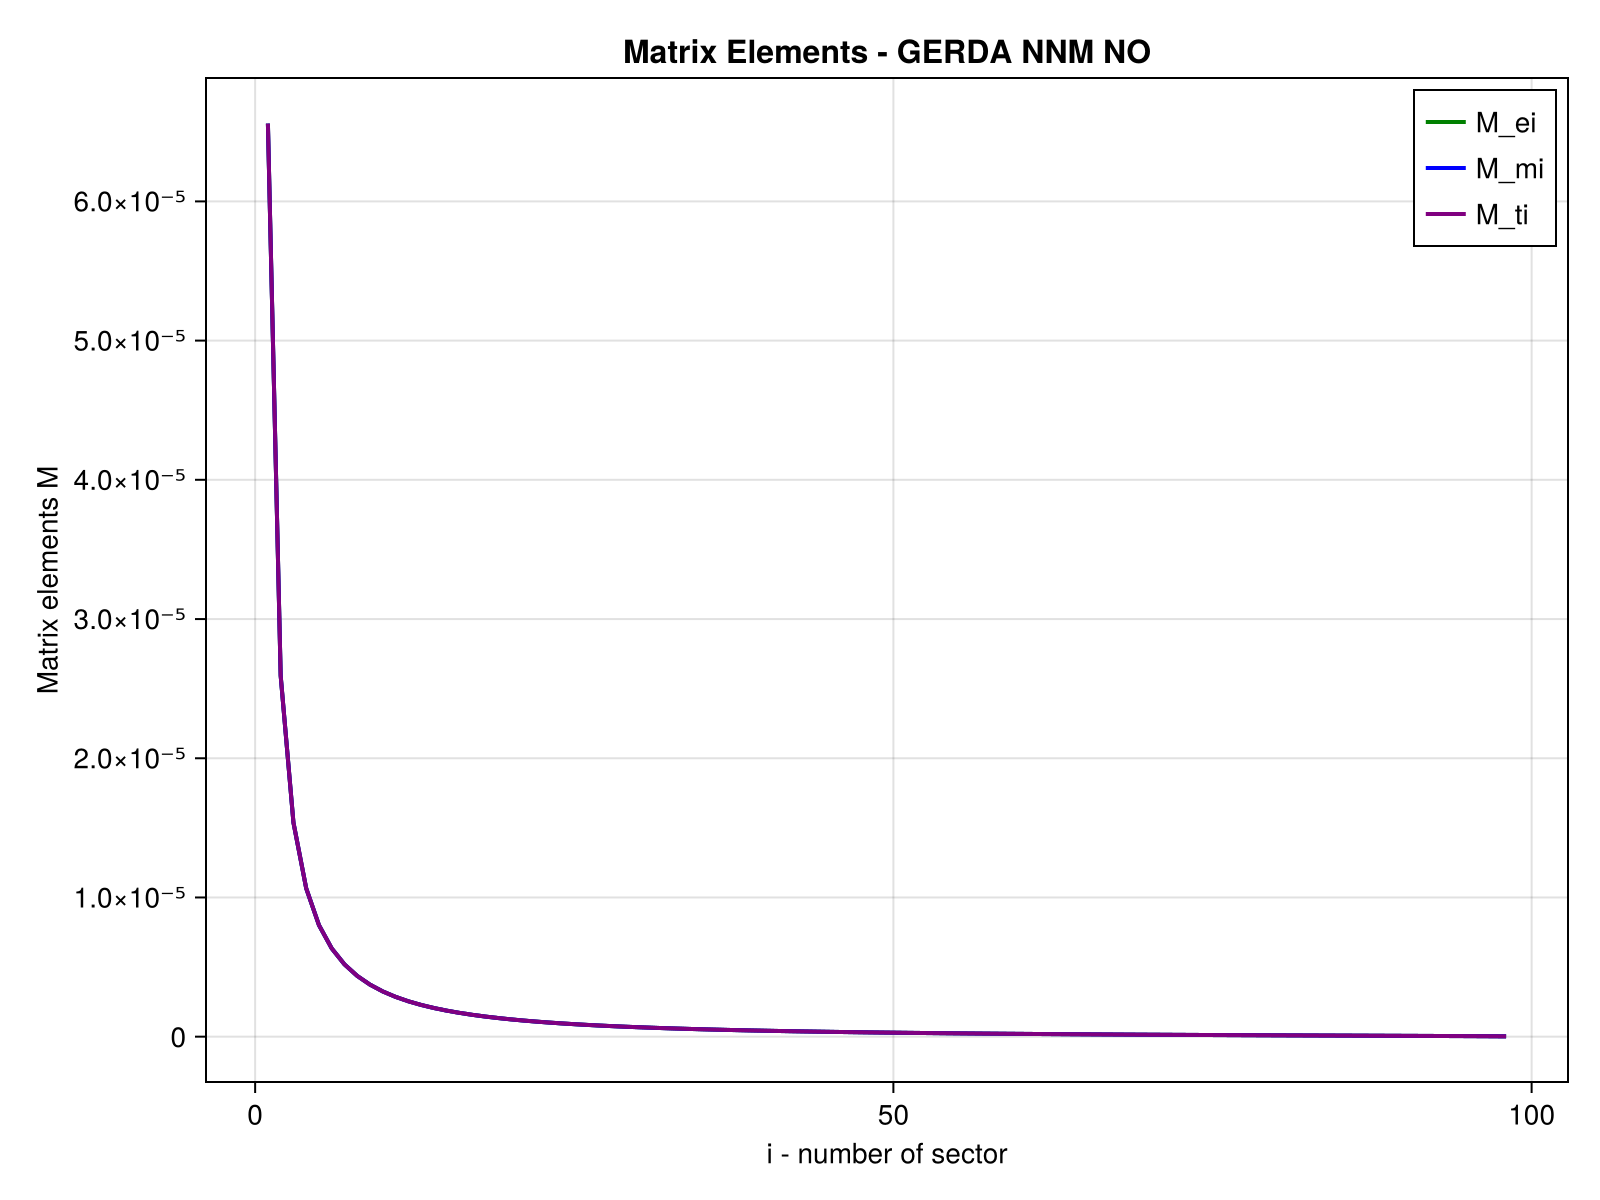

In [15]:
par_p= merge(par, (m₀=0.01, r=1, N=100))   

mass_e, mass_m, mass_t, angles_e, angles_m, angles_t = Newtrinos.gerda.mixing_angles( par_p, osc_cfg.flavour)

angles_e=angles_e[2:end-1].^2
angles_m=angles_m[2:end-1].^2
angles_t=angles_t[2:end-1].^2

mass_e=mass_e[2:end-1]
mass_m=mass_m[2:end-1]
mass_t=mass_t[2:end-1]


# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  "i - number of sector",
    ylabel = "Matrix elements M",
    title = "Matrix Elements - GERDA NNM NO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

i_range=1:length(angles_e)
# Plot the main curve
lines!(ax, i_range, abs.(angles_e),
    color = :green,
    linewidth = 2,
    label = "M_ei"
)

lines!(ax, i_range, abs.(angles_m),
    color = :blue,
    linewidth = 2,
    label = "M_mi"
)

lines!(ax, i_range, abs.(angles_t),
    color = :purple,
    linewidth = 2,
    label = "M_ti"
)
# Add legend
axislegend(ax, position = :rt)  # right bottom

#save("/home/sofialon/Newtrinos.jl/plot_final/katrin_checks/matrix_elements_N=100_m0=0.1_r=1.png", fig)

display("image/png", fig)



┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


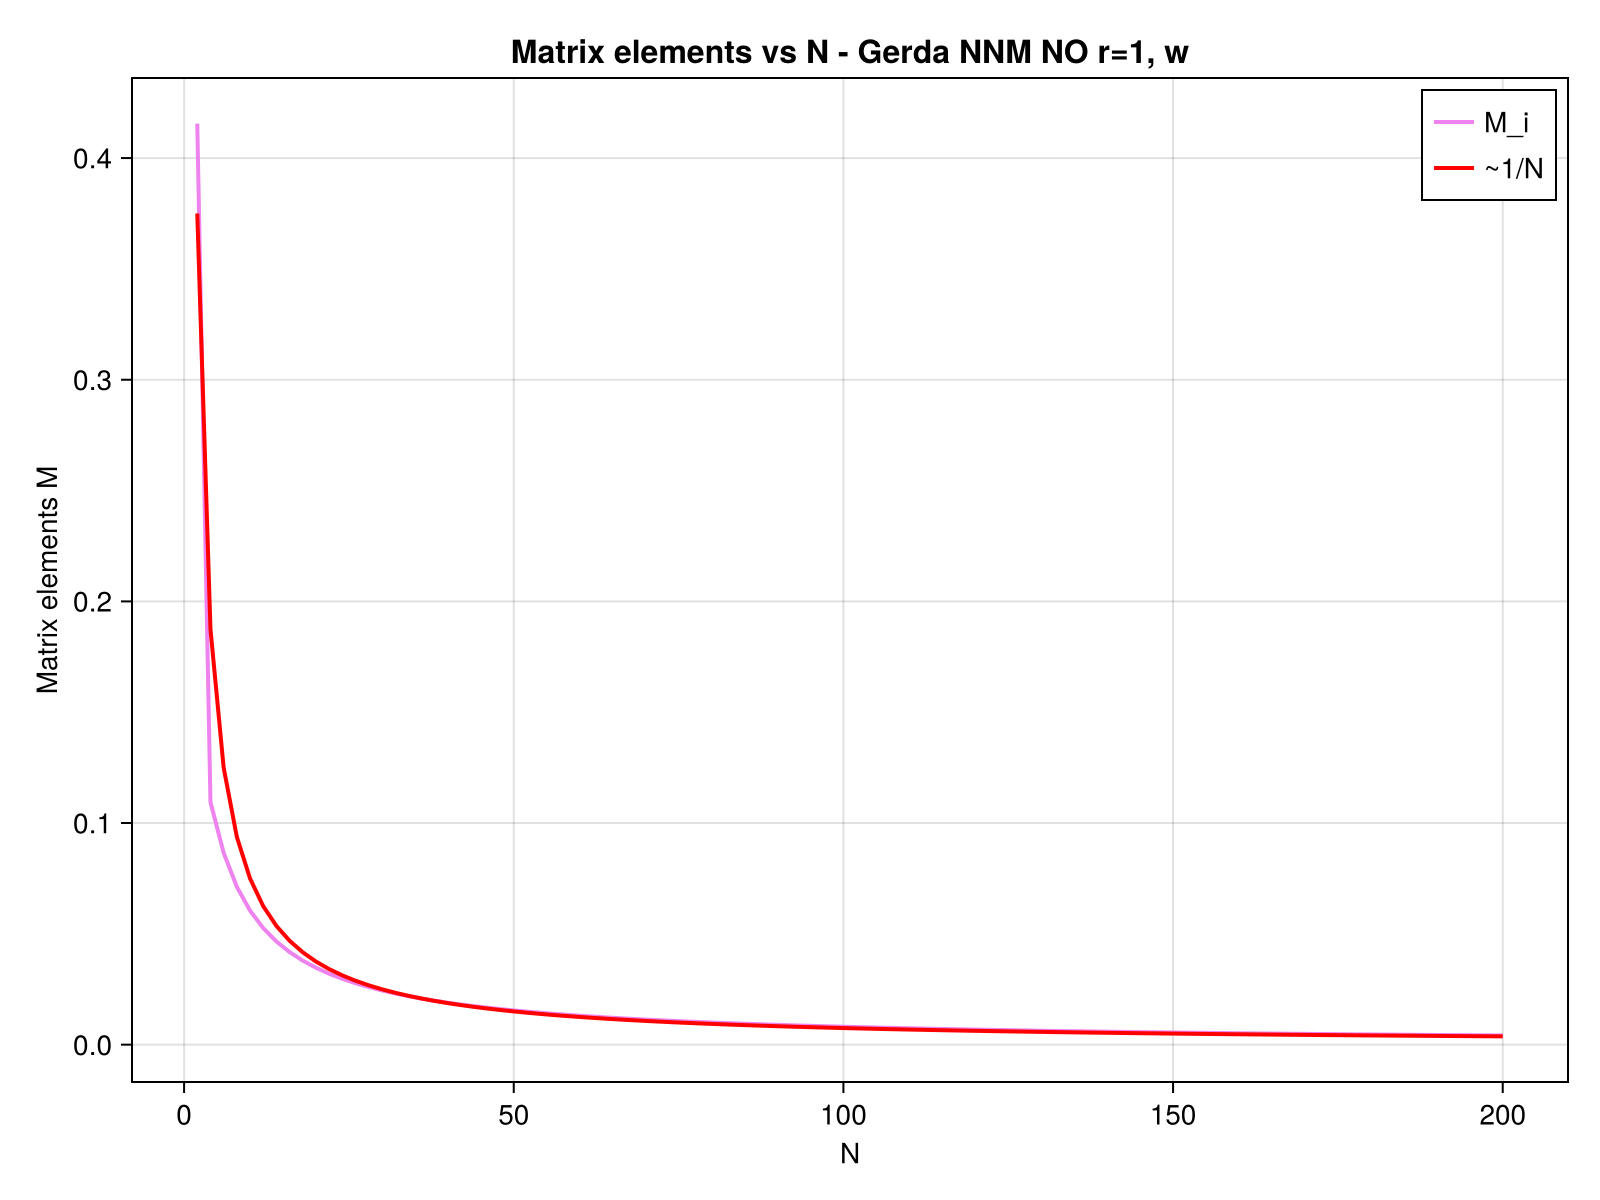

In [16]:

N_range= range(2,200, 100)

angles_e_T=[]
angles_m_T=[]
angles_t_T=[]
behav=[]

for n in N_range

    par_p= merge(par, (m₀=0.01, r=1, N=n))   
    mass_e, mass_m, mass_t, angles_e, angles_m, angles_t = Newtrinos.gerda.mixing_angles( par_p, osc_cfg.flavour)
    push!(angles_e_T, angles_e[2])
    push!(angles_m_T, angles_m[2])
    push!(angles_t_T, angles_t[2])
    push!(behav, (3/4) * 1/n)

end    

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
   xlabel = "N",
   ylabel = "Matrix elements M",
    title = "Matrix elements vs N - Gerda NNM NO r=1, w",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14, 
    #xscale = log10
)


# Plot the main curve
lines!(ax, N_range, angles_e_T,
    color = :violet,
    linewidth = 2,
    label = "M_i"
)





lines!(ax, N_range, behav,
    color = :red,
    linewidth = 2,
    label = "~1/N"
)


axislegend(ax, position = :rt) 
#save("/home/sofialon/Newtrinos.jl/plots_NP/gerda_checks_NP/mbb_N_NNM_NO_nocut.png", fig)


display("image/png", fig)

Scans NN

In [77]:
# NNATURALNESS

using Revise
using Newtrinos

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:IO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   gerda= Newtrinos.gerda.configure(physics),
);

par= Newtrinos.get_params(experiments)

#matrix=Newtrinos.osc.get_matrices(osc_cfg.flavour)(par)
#display(osc_cfg.flavour)

[ Info: Loading Gerda data


(N = 100.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = -0.0024, δCP = 1.0, η = 1.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [ ]:

all_priors = Newtrinos.get_priors(experiments)

m0=0.01

p= merge(par, (m₀=m0,))
  
vars_to_scan = (r=31, N=31)  

modified_priors = (
    N = Uniform(2,200),
    m₀ =all_priors.m₀,
    r = LogUniform(1e-8,1), #all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)
    

likelihood_NN = Newtrinos.generate_likelihood(experiments);

result= Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, p)

#JLD2.@save "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend1000_Nr_m0=$(m0)_η=1+1N_NNM_IO.jld2" result

Number of threads: 4
Total points to compute: 961


Progress: 100%|█████████████████████████████████████████| Time: 0:00:10


TIMING STATISTICS:
  Min time per point: 0.0 ms
  Max time per point: 115.0 ms
  Mean time per point: 21.0 ms
  Median time per point: 18.5 ms
TOTAL TIME:
  Total seconds: 20.12
  Total minutes: 0.34


NewtrinosResult((r = [1.0e-8, 1.8478497974222913e-8, 3.4145488738336024e-8, 6.309573444801935e-8, 1.1659144011798322e-7, 2.1544346900318843e-7, 3.9810717055349756e-7, 7.356422544596415e-7, 1.3593563908785265e-6, 2.5118864315095806e-6  …  0.003981071705534972, 0.007356422544596415, 0.013593563908785288, 0.02511886431509587, 0.04641588833612786, 0.08576958985908957, 0.15848931924611173, 0.29286445646252396, 0.5411695265464654, 1.0000000000000018], N = [2.0, 8.6, 15.2, 21.8, 28.4, 35.0, 41.6, 48.2, 54.8, 61.4  …  140.6, 147.2, 153.8, 160.4, 167.0, 173.6, 180.20000000000002, 186.8, 193.4, 200.0]), (m₀ = [0.1 0.1 … 0.1 0.1; 0.1 0.1 … 0.1 0.1; … ; 0.1 0.1 … 0.1 0.1; 0.1 0.1 … 0.1 0.1], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [-0.0024 -0.0024 … -0.0024 -0.0024; -0.0024 -0.0024 … -0.0024 -0.0024; … ; -0.0024 -0.0024 … -0.0024 -0.0024; -0.0024 -0.0024 … -0.0024 -0.0024], δCP

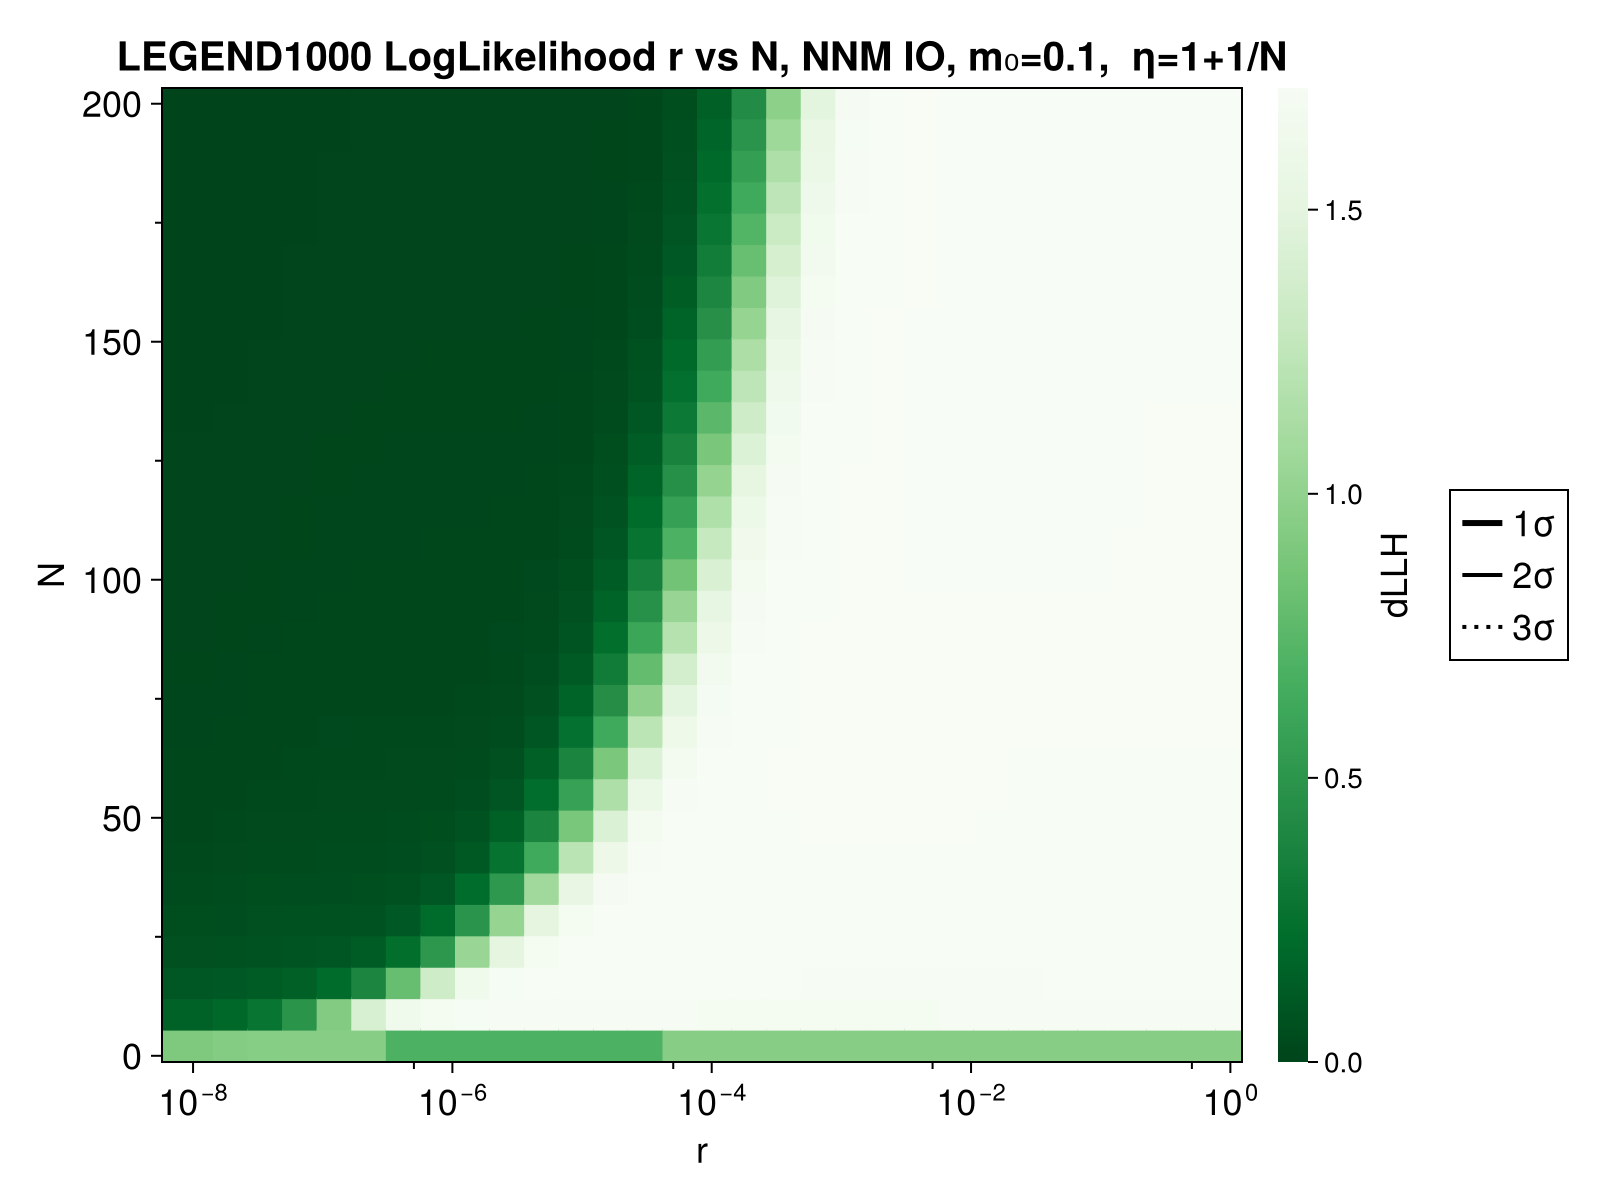

In [88]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result; title="LEGEND1000 LogLikelihood r vs N, NNM IO, m₀=$m0,  η=1+1/N", log=1, mass=0, log_colormap=false)
#save("/home/sofialon/Newtrinos.jl/plots_fix/plots_new/legend1000_Nr_m0=$(m0)_η=1+1N_NNM_IO.png", img)
display("image/png", img)

In [ ]:

all_priors = Newtrinos.get_priors(experiments)

N=200

p= merge(par, (N=N,))
  
vars_to_scan = ( r=31, m₀ =31)  

modified_priors = (
    N = p.N,
    m₀ =LogUniform(1e-6,0.1),
    r = LogUniform(1e-8,1), #all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)
    

likelihood_NN = Newtrinos.generate_likelihood(experiments);

result = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, p)

#JLD2.@save "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend1000_rm0_N=$(N)_η=1+1N_NNM_IO.jld2" result


Number of threads: 4
Total points to compute: 961


Progress: 100%|█████████████████████████████████████████| Time: 0:00:48


TIMING STATISTICS:
  Min time per point: -1375.7 ms
  Max time per point: 1007.3 ms
  Mean time per point: 200.3 ms
  Median time per point: 182.2 ms
TOTAL TIME:
  Total seconds: 192.49
  Total minutes: 3.21


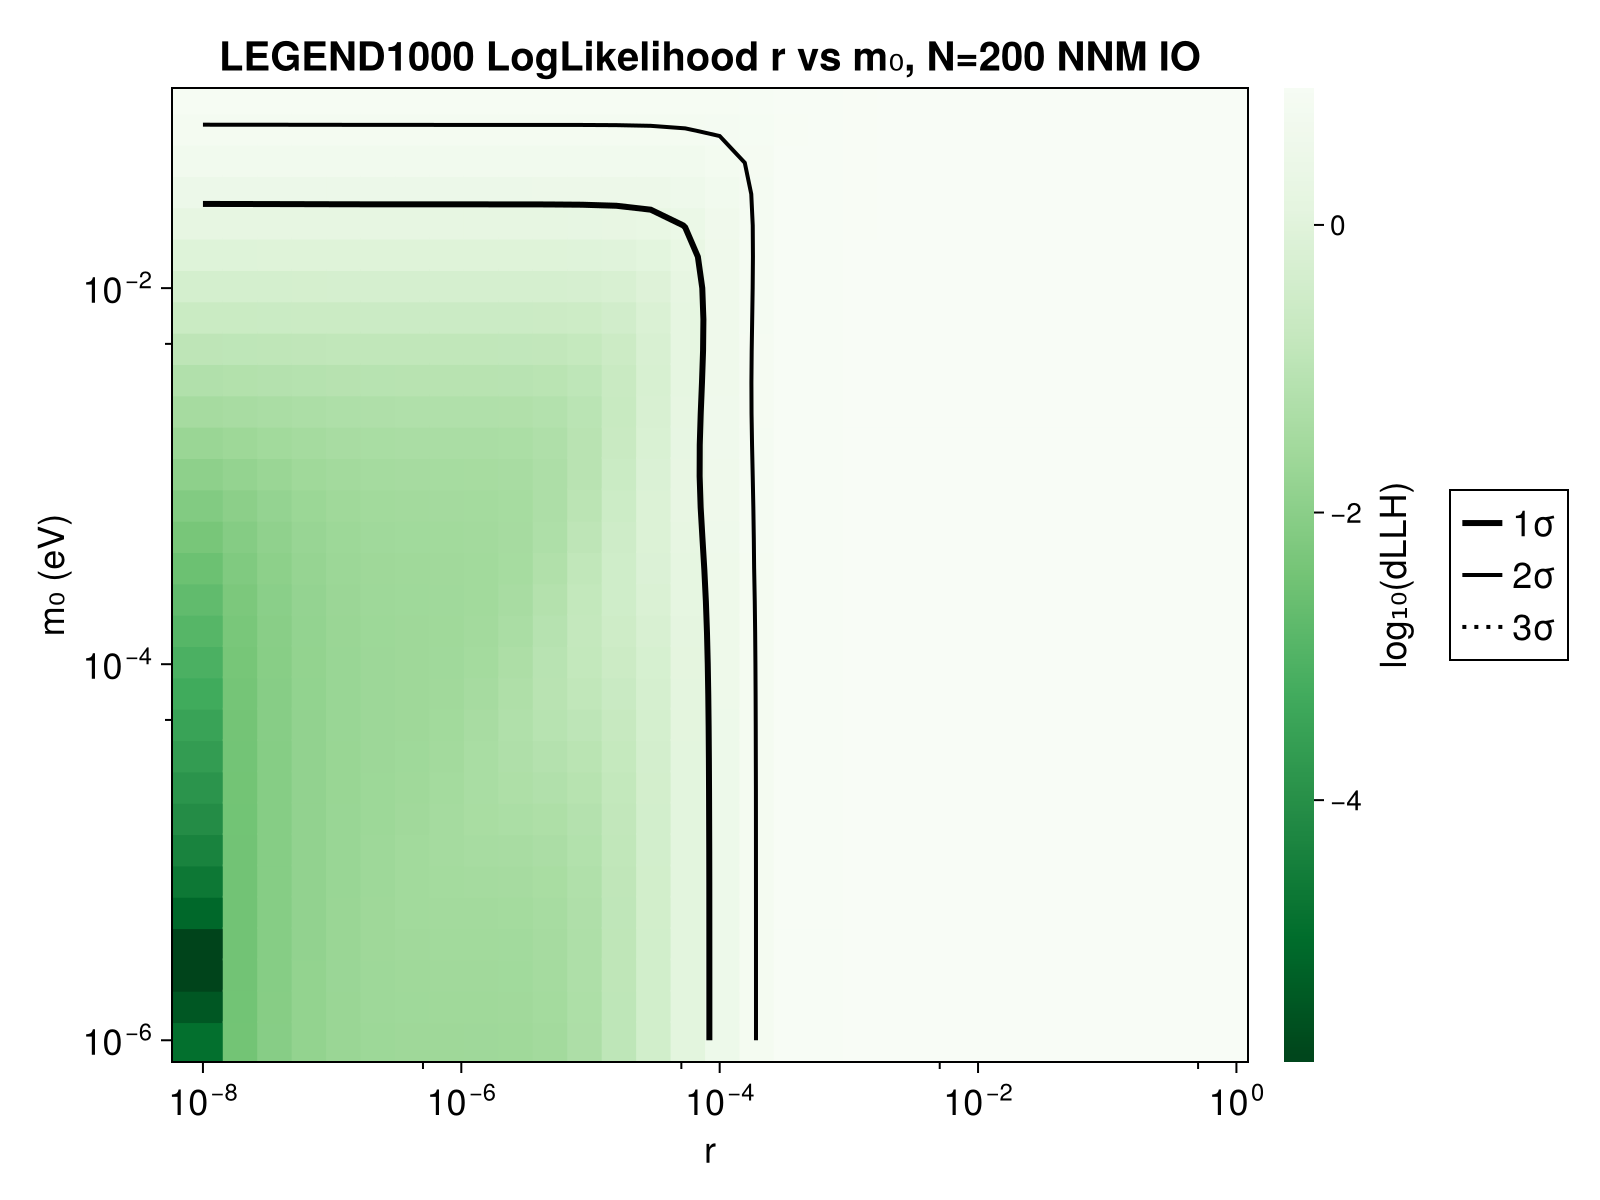

In [ ]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result; title="LEGEND1000 LogLikelihood r vs m₀, N=$N NNM IO", log=3, mass=2, log_colormap=true)
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/plots_fix/plots_new/legend1000_rm₀_N=$(N)_η=1+1N_NNM_IO.png", img)

In [82]:

all_priors = Newtrinos.get_priors(experiments)

rr=1

par= merge(p, (r=rr,))
  
vars_to_scan = ( m₀=31, N=31)  

modified_priors = (
    N = DiscreteUniform(2,100),
    m₀ =all_priors.m₀,
    r = par.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,   
    θ₂₃ = par.θ₂₃
)
    

likelihood_NN = Newtrinos.generate_likelihood(experiments);

result = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)

#JLD2.@save "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend1000_m0N_r=$(rr)_η=1+1N_NNM_IO.jld2" result


Number of threads: 4
Total points to compute: 961
TIMING STATISTICS:
  Min time per point: 0.0 ms
  Max time per point: 65.2 ms
  Mean time per point: 4.5 ms
  Median time per point: 3.3 ms
TOTAL TIME:
  Total seconds: 4.36
  Total minutes: 0.07


NewtrinosResult((m₀ = [1.0e-6, 1.4342746860173907e-6, 2.057143874950285e-6, 2.950509385336919e-6, 4.231840922245473e-6, 6.069622310029172e-6, 8.705505632961242e-6, 1.2486086358338112e-5, 1.790847759119142e-5, 2.568567607415555e-5  …  0.0019466102373808657, 0.0027919737870176794, 0.004004457326743574, 0.005743491774985179, 0.008237744862210334, 0.0118151889257381, 0.016946226386699164, 0.024305543529962562, 0.03486082581491908, 0.05], N = [2, 5, 8, 11, 15, 18, 21, 25, 28, 31  …  71, 74, 77, 81, 84, 87, 91, 94, 97, 100]), (r = [1 1 … 1 1; 1 1 … 1 1; … ; 1 1 … 1 1; 1 1 … 1 1], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [-0.0024 -0.0024 … -0.0024 -0.0024; -0.0024 -0.0024 … -0.0024 -0.0024; … ; -0.0024 -0.0024 … -0.0024 -0.0024; -0.0024 -0.0024 … -0.0024 -0.0024], δCP = [1.0 1.0 … 1.0 1.0; 1.0 1.0 … 1.0 1.0; … ; 1.0 1.0 … 1.0 1.0; 1.0 1.0 … 1.0 1.0], η = [1.01 1.01 … 1.01 1

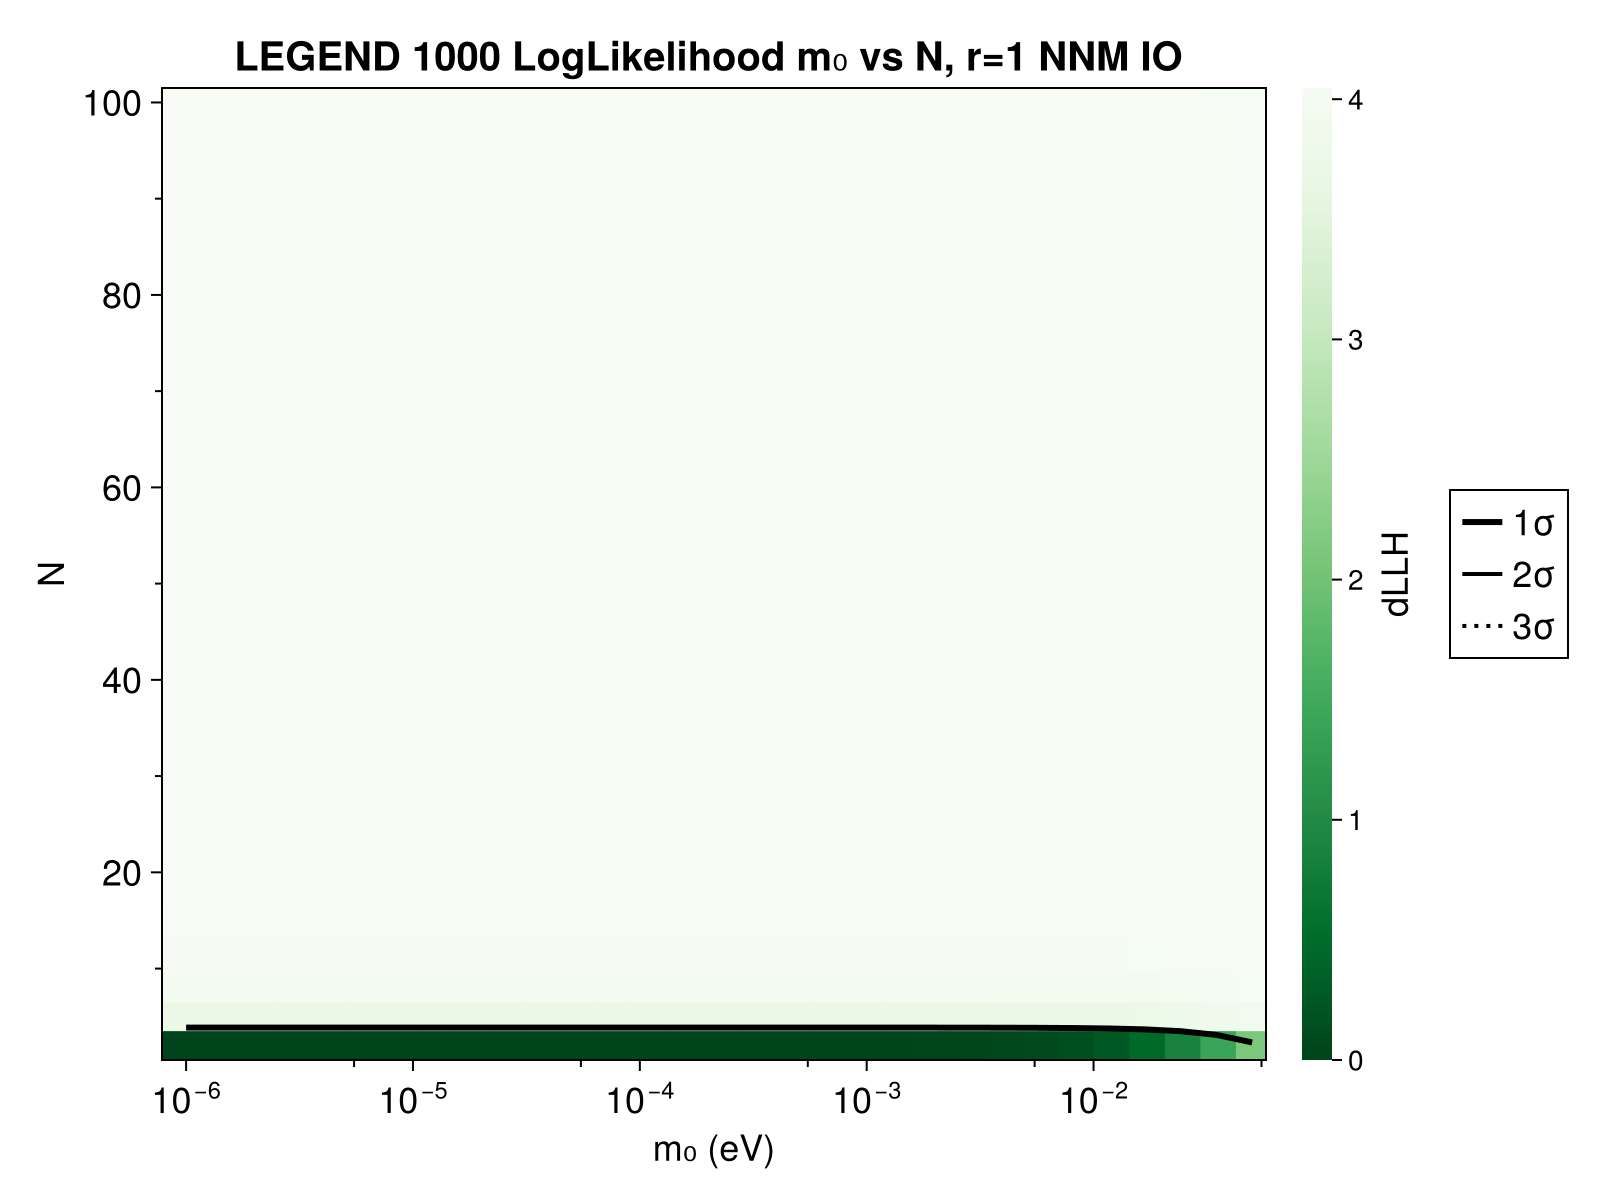

In [83]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result; title="LEGEND 1000 LogLikelihood m₀ vs N, r=$rr NNM IO ", log=1, mass=1)
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/plots_fix/plots_new/legend1000_m0N_r=$(rr)_η=1+1N_NNM_IO.png", img)


In [84]:
using CairoMakie

r_values = [1, 1e-4, 1e-5, 1e-6]
results = []

for rr in r_values
    par = merge(p, (r=rr,))
    vars_to_scan = (m₀=20, N=20)
    
    modified_priors = (
        N = DiscreteUniform(2, 100),
        m₀ = all_priors.m₀,
        r = par.r,
        Δm²₂₁ = par.Δm²₂₁,
        Δm²₃₁ = all_priors.Δm²₃₁,
        δCP = par.δCP,
        θ₁₂ = par.θ₁₂,
        θ₁₃ = all_priors.θ₁₃,
        θ₂₃ = par.θ₂₃
    )
    
    likelihood_NN = Newtrinos.generate_likelihood(experiments)
    result_NN = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)
    push!(results, result_NN)
end

# Create single figure with all r values overlaid
fig = Figure(size=(1200, 900))
ax = Axis(fig[1, 1],
    xlabel="m₀ (eV)",
    ylabel="N",
    title="GERDA LogLikelihood m₀ vs N - NNM NO",
    xscale=log10,
    xminorticksvisible=true,
    xminorgridvisible=true,
    yminorticksvisible=true,
    yminorgridvisible=true
)

# Colors for each r value
colors = [:"#1f77b4", :"#ff7f0e", :"#2ca02c", :"#d62728"]  # blue, orange, green, red
sigma_levels = [2.28, 6.17]  # 1σ and 2σ only

# Plot each result
for (rr, result, color) in zip(r_values, results, colors)
    dLLH = 2 * (maximum(result.values.log_posterior) .- result.values.log_posterior)
    
    contour!(ax, result.axes[1], result.axes[2], dLLH,
        levels=sigma_levels,
        color=color,
        linewidth=2.5,
        label="r = $rr")
end

# Create legend with LineElements showing colors
legend_elements = [LineElement(color=color, linewidth=3) for color in colors]
legend_labels = ["r = $rr" for rr in r_values]

Legend(fig[1, 2],
    legend_elements,
    legend_labels,
    framevisible=true,
    labelsize=12,
    rowgap=8)

# Save and display
#save("contours_all_r_superposed.png", fig)
println("Plot saved as: contours_all_r_superposed.png")
display(""fig)

Number of threads: 4
Total points to compute: 400
TIMING STATISTICS:
  Min time per point: 0.0 ms
  Max time per point: 16.7 ms
  Mean time per point: 4.0 ms
  Median time per point: 2.8 ms
TOTAL TIME:
  Total seconds: 1.62
  Total minutes: 0.03
Number of threads: 4
Total points to compute: 400
TIMING STATISTICS:
  Min time per point: 0.0 ms
  Max time per point: 47.3 ms
  Mean time per point: 4.8 ms
  Median time per point: 4.0 ms
TOTAL TIME:
  Total seconds: 1.93
  Total minutes: 0.03
Number of threads: 4
Total points to compute: 400


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00

TIMING STATISTICS:
  Min time per point: 0.0 ms
  Max time per point: 19.4 ms
  Mean time per point: 4.5 ms
  Median time per point: 3.6 ms
TOTAL TIME:
  Total seconds: 1.78
  Total minutes: 0.03
Number of threads: 4
Total points to compute: 400



Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


TIMING STATISTICS:
  Min time per point: 0.0 ms
  Max time per point: 17.3 ms
  Mean time per point: 4.4 ms
  Median time per point: 3.6 ms
TOTAL TIME:
  Total seconds: 1.76
  Total minutes: 0.03
Plot saved as: contours_all_r_superposed.png


LoadError: ParseError:
[90m# Error @ [0;0m]8;;file:///home/sofialon/Newtrinos.jl/src/experiments/gerda/In[84]#69:11\[90mIn[84]:69:11[0;0m]8;;\
println("Plot saved as: contours_all_r_superposed.png")
display(""[48;2;120;70;70m[0;0mfig)
[90m#         └ ── [0;0m[91mcannot juxtapose string literal[0;0m

Mixing angles

In [ ]:
par_p= merge(par, (m₀=0.01, r=1e-3, N=100))   

mass_e, mass_m, mass_t, angles_e, angles_m, angles_t = Newtrinos.gerda.mixing_angles( par_p, osc_cfg.flavour)

angles_e=angles_e[2:end-1]
angles_m=angles_m[2:end-1]
angles_t=angles_t[2:end-1]

mass_e=mass_e[2:end-1]
mass_m=mass_m[2:end-1]
mass_t=mass_t[2:end-1]


cont_e=mass_e.*(angles_e).^2
cont_m=mass_m.*(angles_m).^2
cont_t=mass_t.*(angles_t).^2






98-element Vector{Float64}:
 2.1828043819182195e-8
 4.1166237178715924e-8
 5.879659959626954e-8
 7.509516135958231e-8
 9.02998918265414e-8
 1.0457727961723547e-7
 1.1805090068848432e-7
 1.308162112318709e-7
 1.4294912108189158e-7
 1.545113567420312e-7
 1.655540081926324e-7
 1.7611997690082717e-7
 1.862457236445792e-7
 ⋮
 3.036394814850212e-7
 2.9509021580067305e-7
 2.8581155297629934e-7
 2.7570285859359085e-7
 2.6463397740556973e-7
 2.5243129935275703e-7
 2.388539934817246e-7
 2.2355034156157737e-7
 2.0596913353883425e-7
 1.8515282871610135e-7
 1.5913824066814774e-7
 1.2238035903476744e-7

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


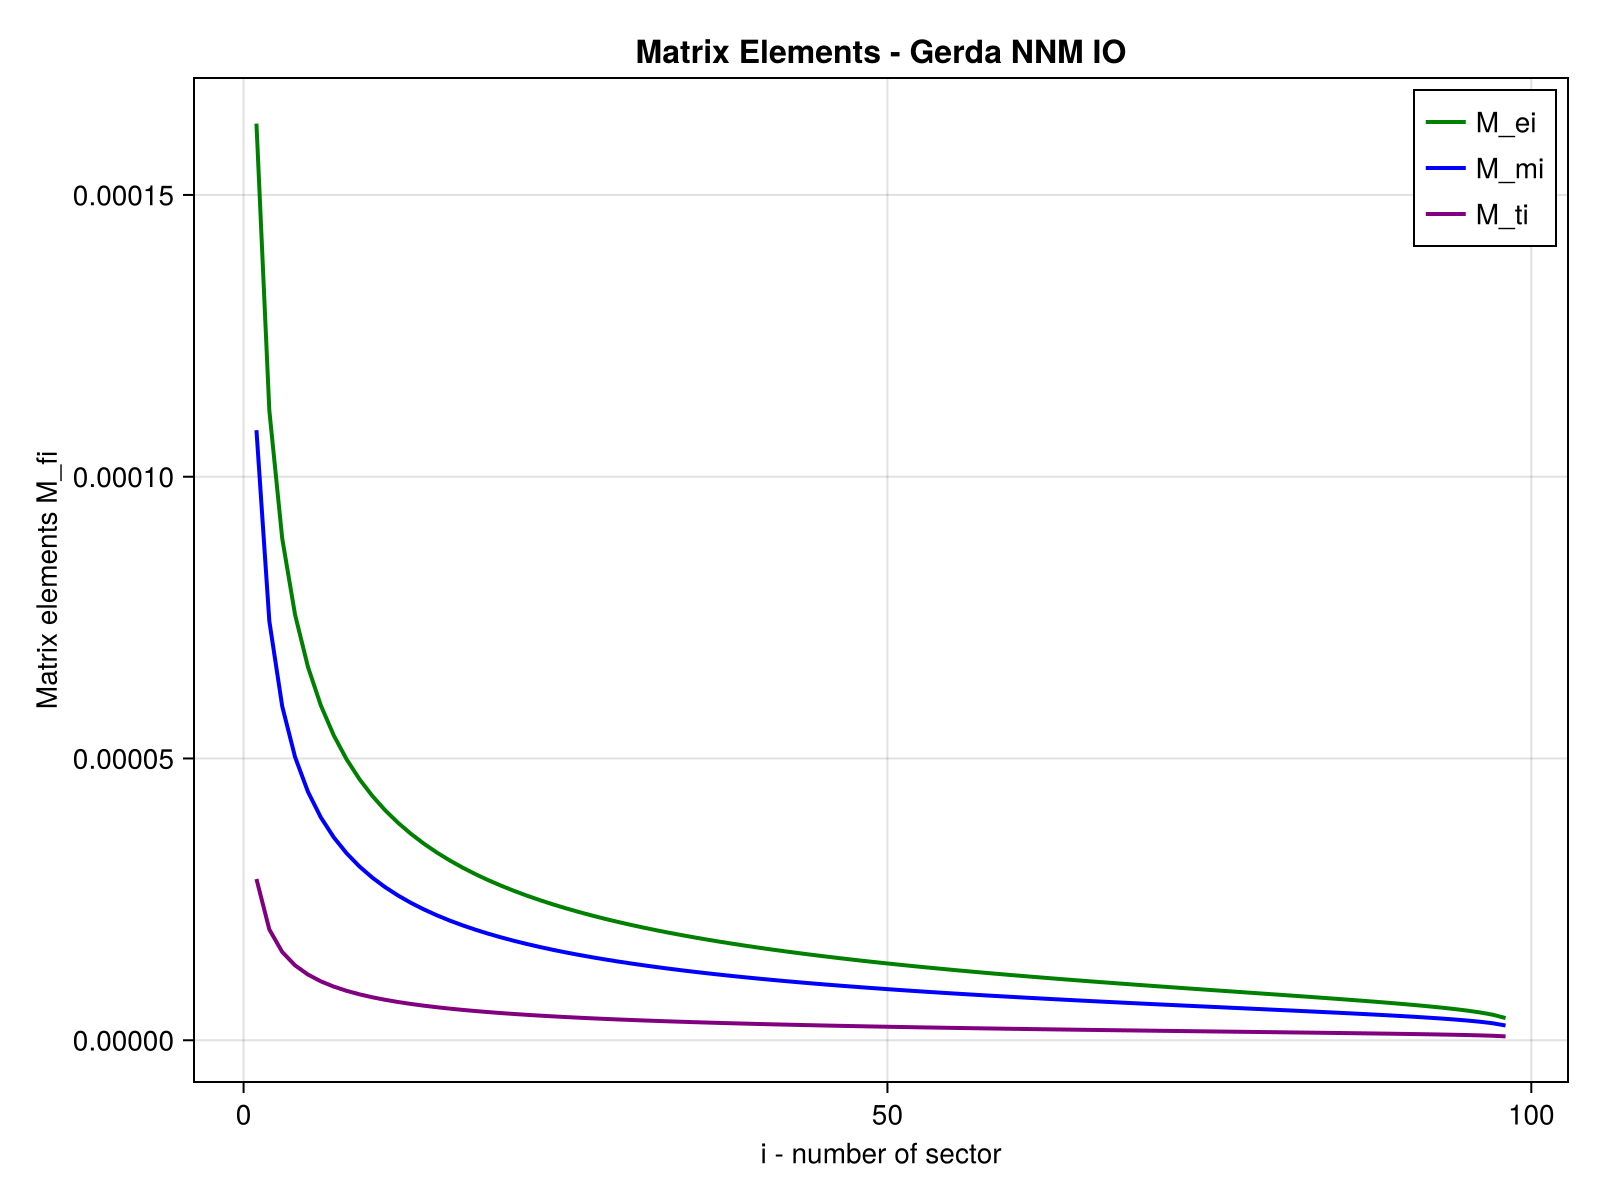

In [ ]:
using CairoMakie
# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  "i - number of sector",
    ylabel = "Matrix elements M_fi",
    title = "Matrix Elements - Gerda NNM IO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

i_range=1:length(angles_e)
# Plot the main curve
lines!(ax, i_range, abs.(angles_e),
    color = :green,
    linewidth = 2,
    label = "M_ei"
)

lines!(ax, i_range, abs.(angles_m),
    color = :blue,
    linewidth = 2,
    label = "M_mi"
)

lines!(ax, i_range, abs.(angles_t),
    color = :purple,
    linewidth = 2,
    label = "M_ti"
)
# Add legend
axislegend(ax, position = :rt)  # right bottom

#save("/home/sofialon/Newtrinos.jl/plot_final/gerda_checks/matrix_elements_N=100_m0=0.1_r=10^-3.png", fig)

display("image/png", fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


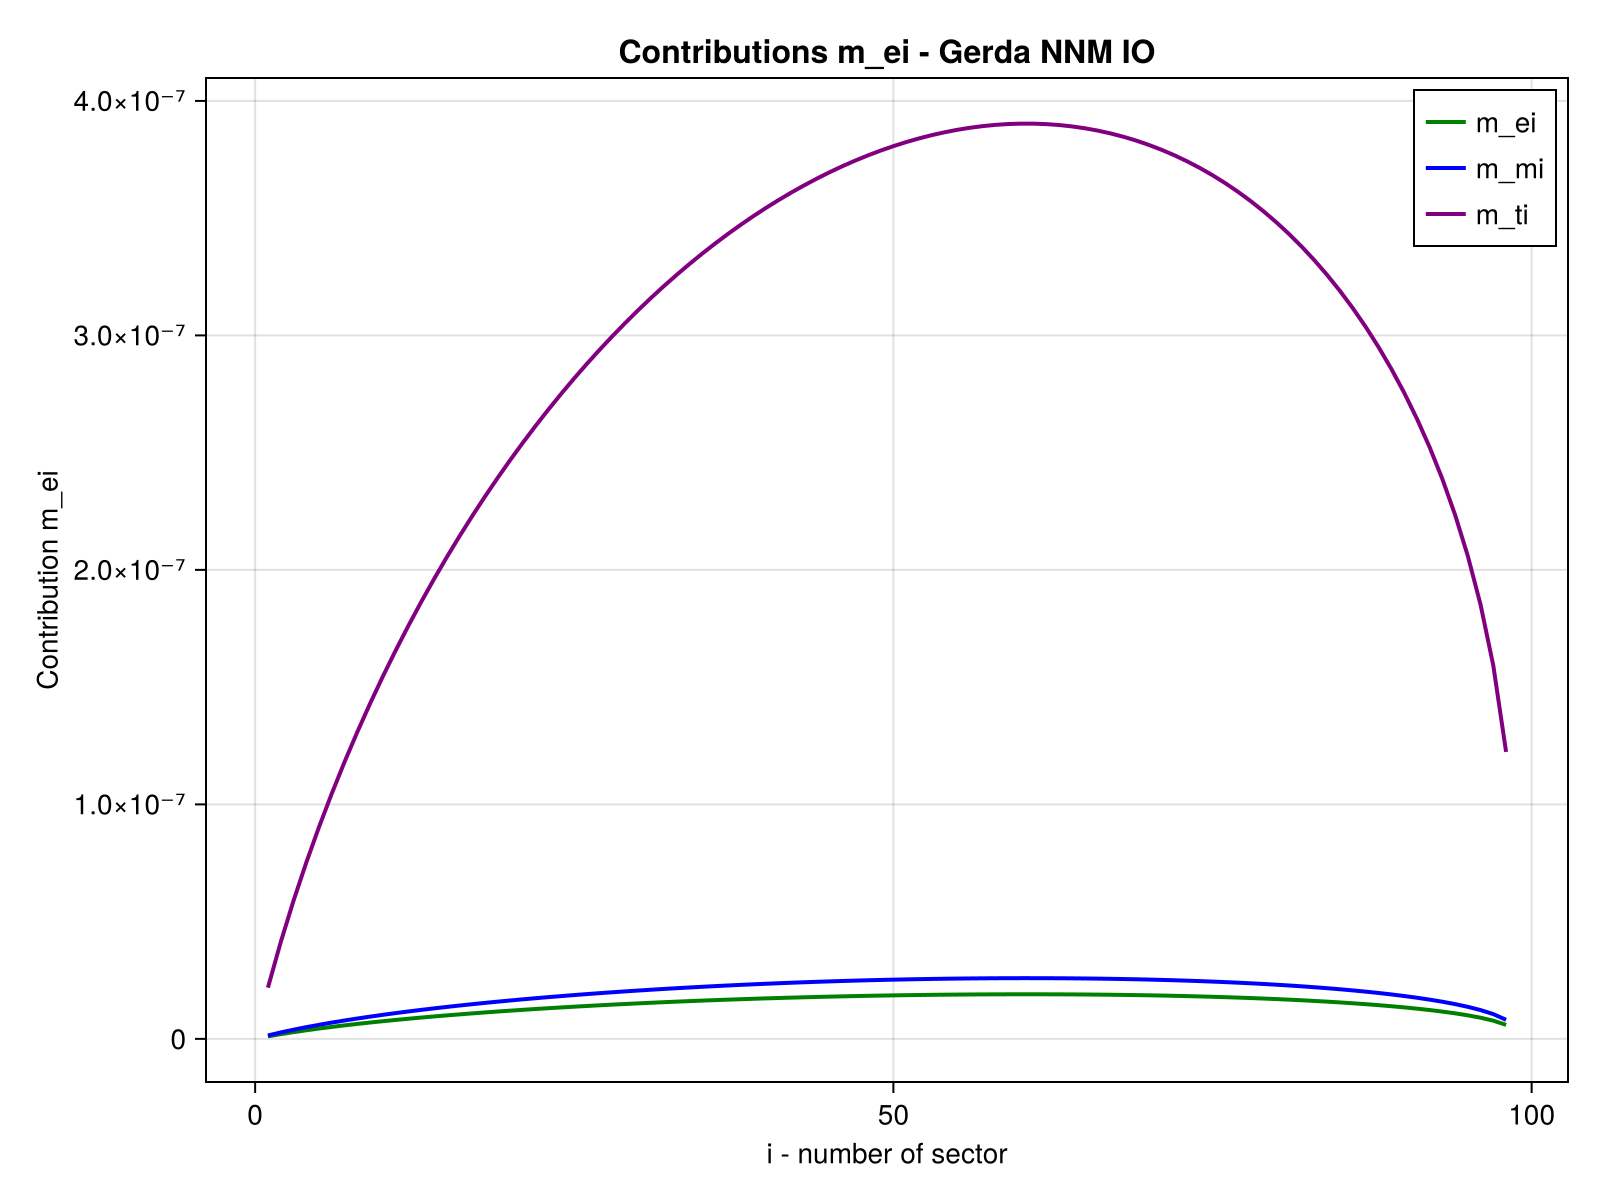

In [ ]:

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  "i - number of sector",
    ylabel = "Contribution m_ei",
    title = "Contributions m_ei - Gerda NNM IO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

i_range=1:length(angles_e)
# Plot the main curve
lines!(ax, i_range, cont_e,
    color = :green,
    linewidth = 2,
    label = "m_ei"
)

lines!(ax, i_range, cont_m,
    color = :blue,
    linewidth = 2,
    label = "m_mi"
)

lines!(ax, i_range, cont_t,
    color = :purple,
    linewidth = 2,
    label = "m_ti"
)
# Add legend
axislegend(ax, position = :rt)  # right bottom

#save("/home/sofialon/Newtrinos.jl/plot_final/gerda_checks/m_contributions_N=100_m0=0.1_r=10^-3.png", fig)


display("image/png", fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


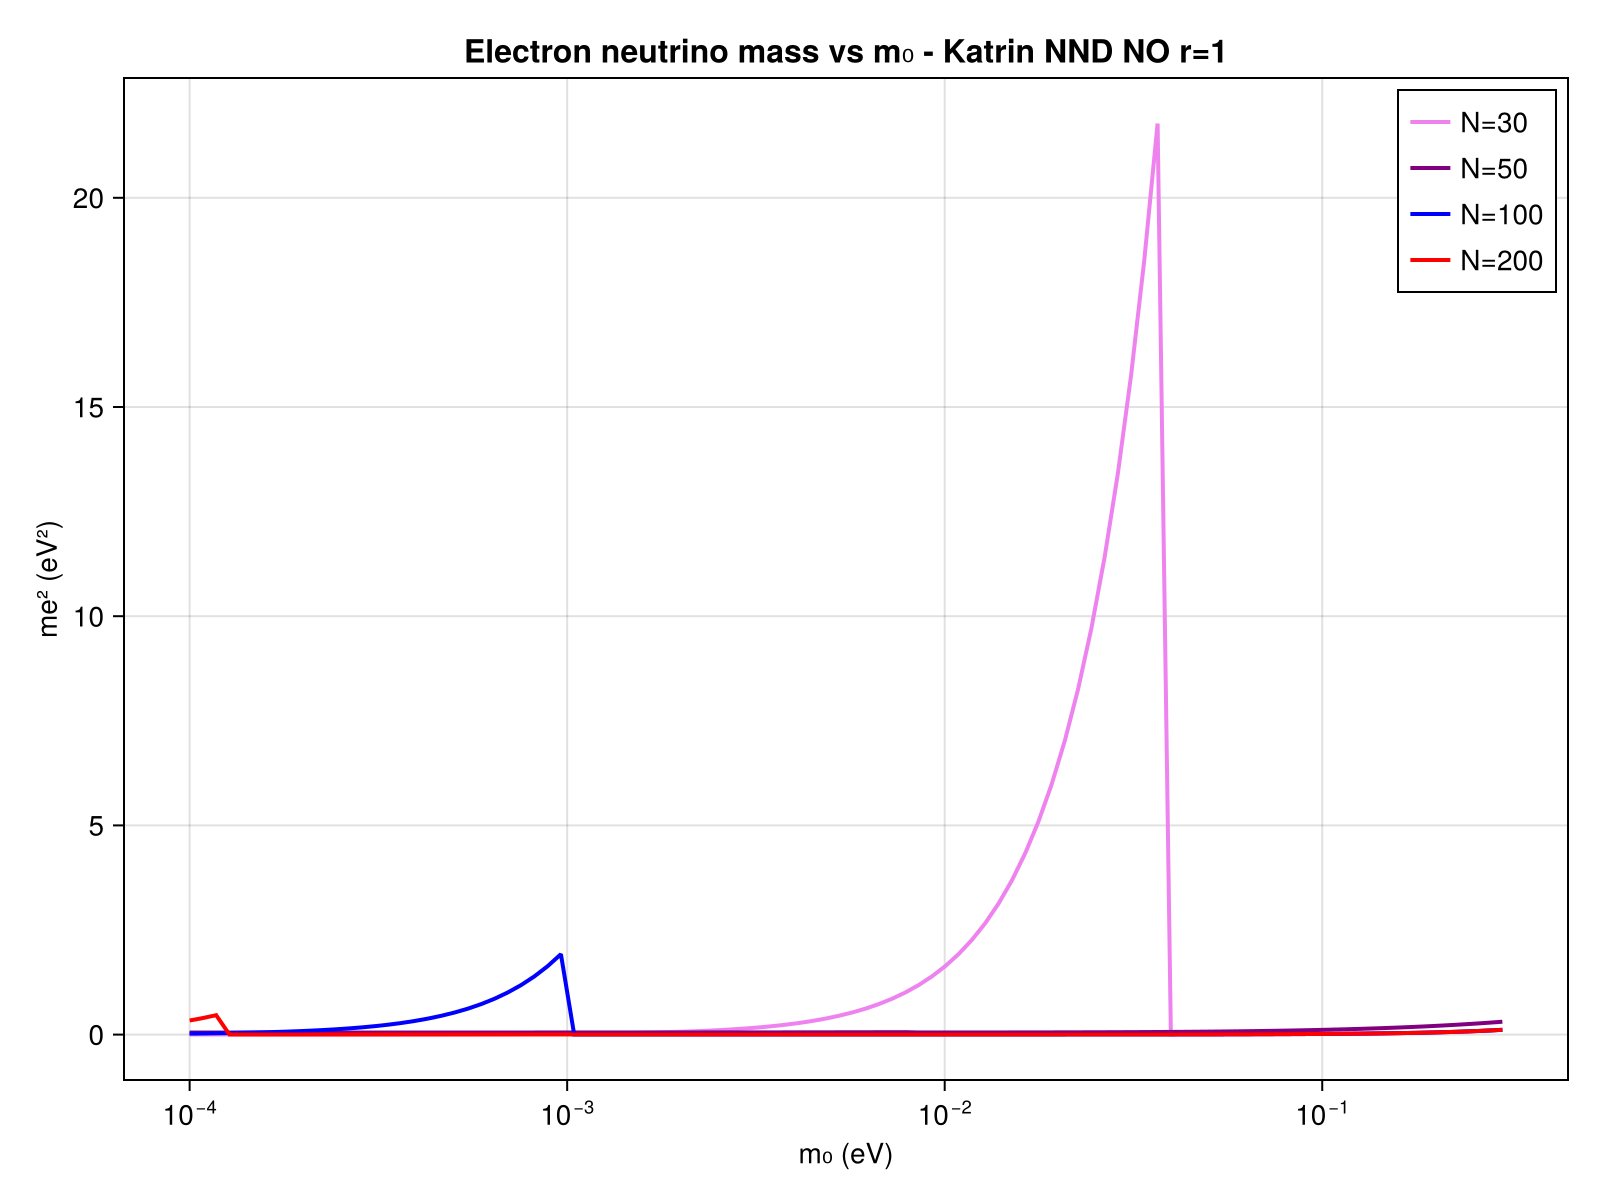

In [ ]:
m0_range= logrange(1e-4, 0.3, 100)

mass_nu_0=[]
mass_nu_1=[]
mass_nu_2=[]
mass_nu_3=[]

for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=30))   
    mass = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_0, mass)
    
end    

for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=50))   
    mass = Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_1, mass)
    
end    

for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=100))   
    mass = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_2, mass)
    
end    


for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=200))   
    mass = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_3, mass)
    
end    


# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
   xlabel = "m₀ (eV)",
   ylabel = "me² (eV²)",
    title = "Electron neutrino mass vs m₀ - Katrin NND NO r=1",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14, 
    xscale = log10
)


# Plot the main curve
lines!(ax, m0_range, mass_nu_0,
    color = :violet,
    linewidth = 2,
    label = "N=30"
)


# Plot the main curve
lines!(ax, m0_range, mass_nu_1,
    color = :purple,
    linewidth = 2,
    label = "N=50"
)

lines!(ax, m0_range, mass_nu_2,
    color = :blue,
    linewidth = 2,
    label = "N=100"
)

lines!(ax, m0_range, mass_nu_3,
    color = :red,
    linewidth = 2,
    label = "N=200"
)

axislegend(ax, position = :rt) 
#save("/home/sofialon/Newtrinos.jl/plots_NP/katrin_checks/me_m0_NND_NO.png", fig)


display("image/png", fig)

Naive comparison 

In [ ]:
#predicted values comparison

using Revise
using Newtrinos


m0_range= LinRange(1e-7, 1e-2, 100)
r_range=LinRange(0, 1.0, 100)

predicted=[]

for m₀ in m0_range
    for r in r_range
        par_new = merge(par, (m₀=m₀, r=r, N=30))    
        pred, twosigma = Newtrinos.gerda.comparing_times(osc_cfg.flavour, experiments, par_new)
        push!(predicted, pred)
    end
end


In [ ]:
using CairoMakie

# plotting
observed_dist = Normal(experiments.gerda.assets.observed, 0.1*1e26)
observed_mean = mean(observed_dist)
observed_sigma = std(observed_dist)

# Get the actual lengths
n_r = length(r_range)
n_m0 = length(m0_range)

# Reshape predicted values into 2D array
predicted_2d = reshape(predicted, n_r, n_m0)

lower_bound = observed_mean - 2 * observed_sigma
upper_bound = observed_mean + 2 * observed_sigma
within_2sigma = (predicted_2d .>= lower_bound)

# Convert boolean matrix to numeric (1 for within, 0 for outside)
within_numeric = Float64.(within_2sigma)

# Create the plot with heatmap
fig = Figure(size=(1000, 800))
ax = Axis(fig[1, 1],
    ylabel="m₀",
    xlabel="r",
    title="Thalf Predictions - NNM NO, N=30",
    titlesize=24,
    xlabelsize=18,
    ylabelsize=18)

# Use heatmap with blue/green colormap
heatmap!(ax, r_range, m0_range, within_numeric,
    colormap=[:lightblue, :blue])

# Add legend box with text
text!(ax, 0.98, 0.98,
    text="Blue: Within 2σ",
    space=:relative, fontsize=14, align=(:right, :top),
    color=:black)

# Draw a box around the legend using lines
lines!(ax, [0.85, 0.99, 0.99, 0.85, 0.85], [0.90, 0.90, 0.99, 0.99, 0.90],
    space=:relative, color=:black, linewidth=2)

#save("/home/sofialon/Newtrinos.jl/plot_final/scans/gerda/Thalf_NNM_NO_rm0_N=30.png", fig)
display(fig)

LoadError: UndefVarError: `Normal` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name may be made accessible by importing Distributions in the current active module Main
Hint: a global variable of this name may be made accessible by importing GeometryBasics in the current active module Main

In [ ]:


N_range= LinRange(1, 50, 100)
r_range=LinRange(0, 1.0, 100)

predicted_N=[]

for N in N_range
    for r in r_range
        par_new = merge(par, (N=N, r=r, m₀=0.0001))    
        pred, twosigma = Newtrinos.gerda.comparing_times(osc_cfg.flavour, experiments, par_new)
        push!(predicted_N, pred)
    end
end



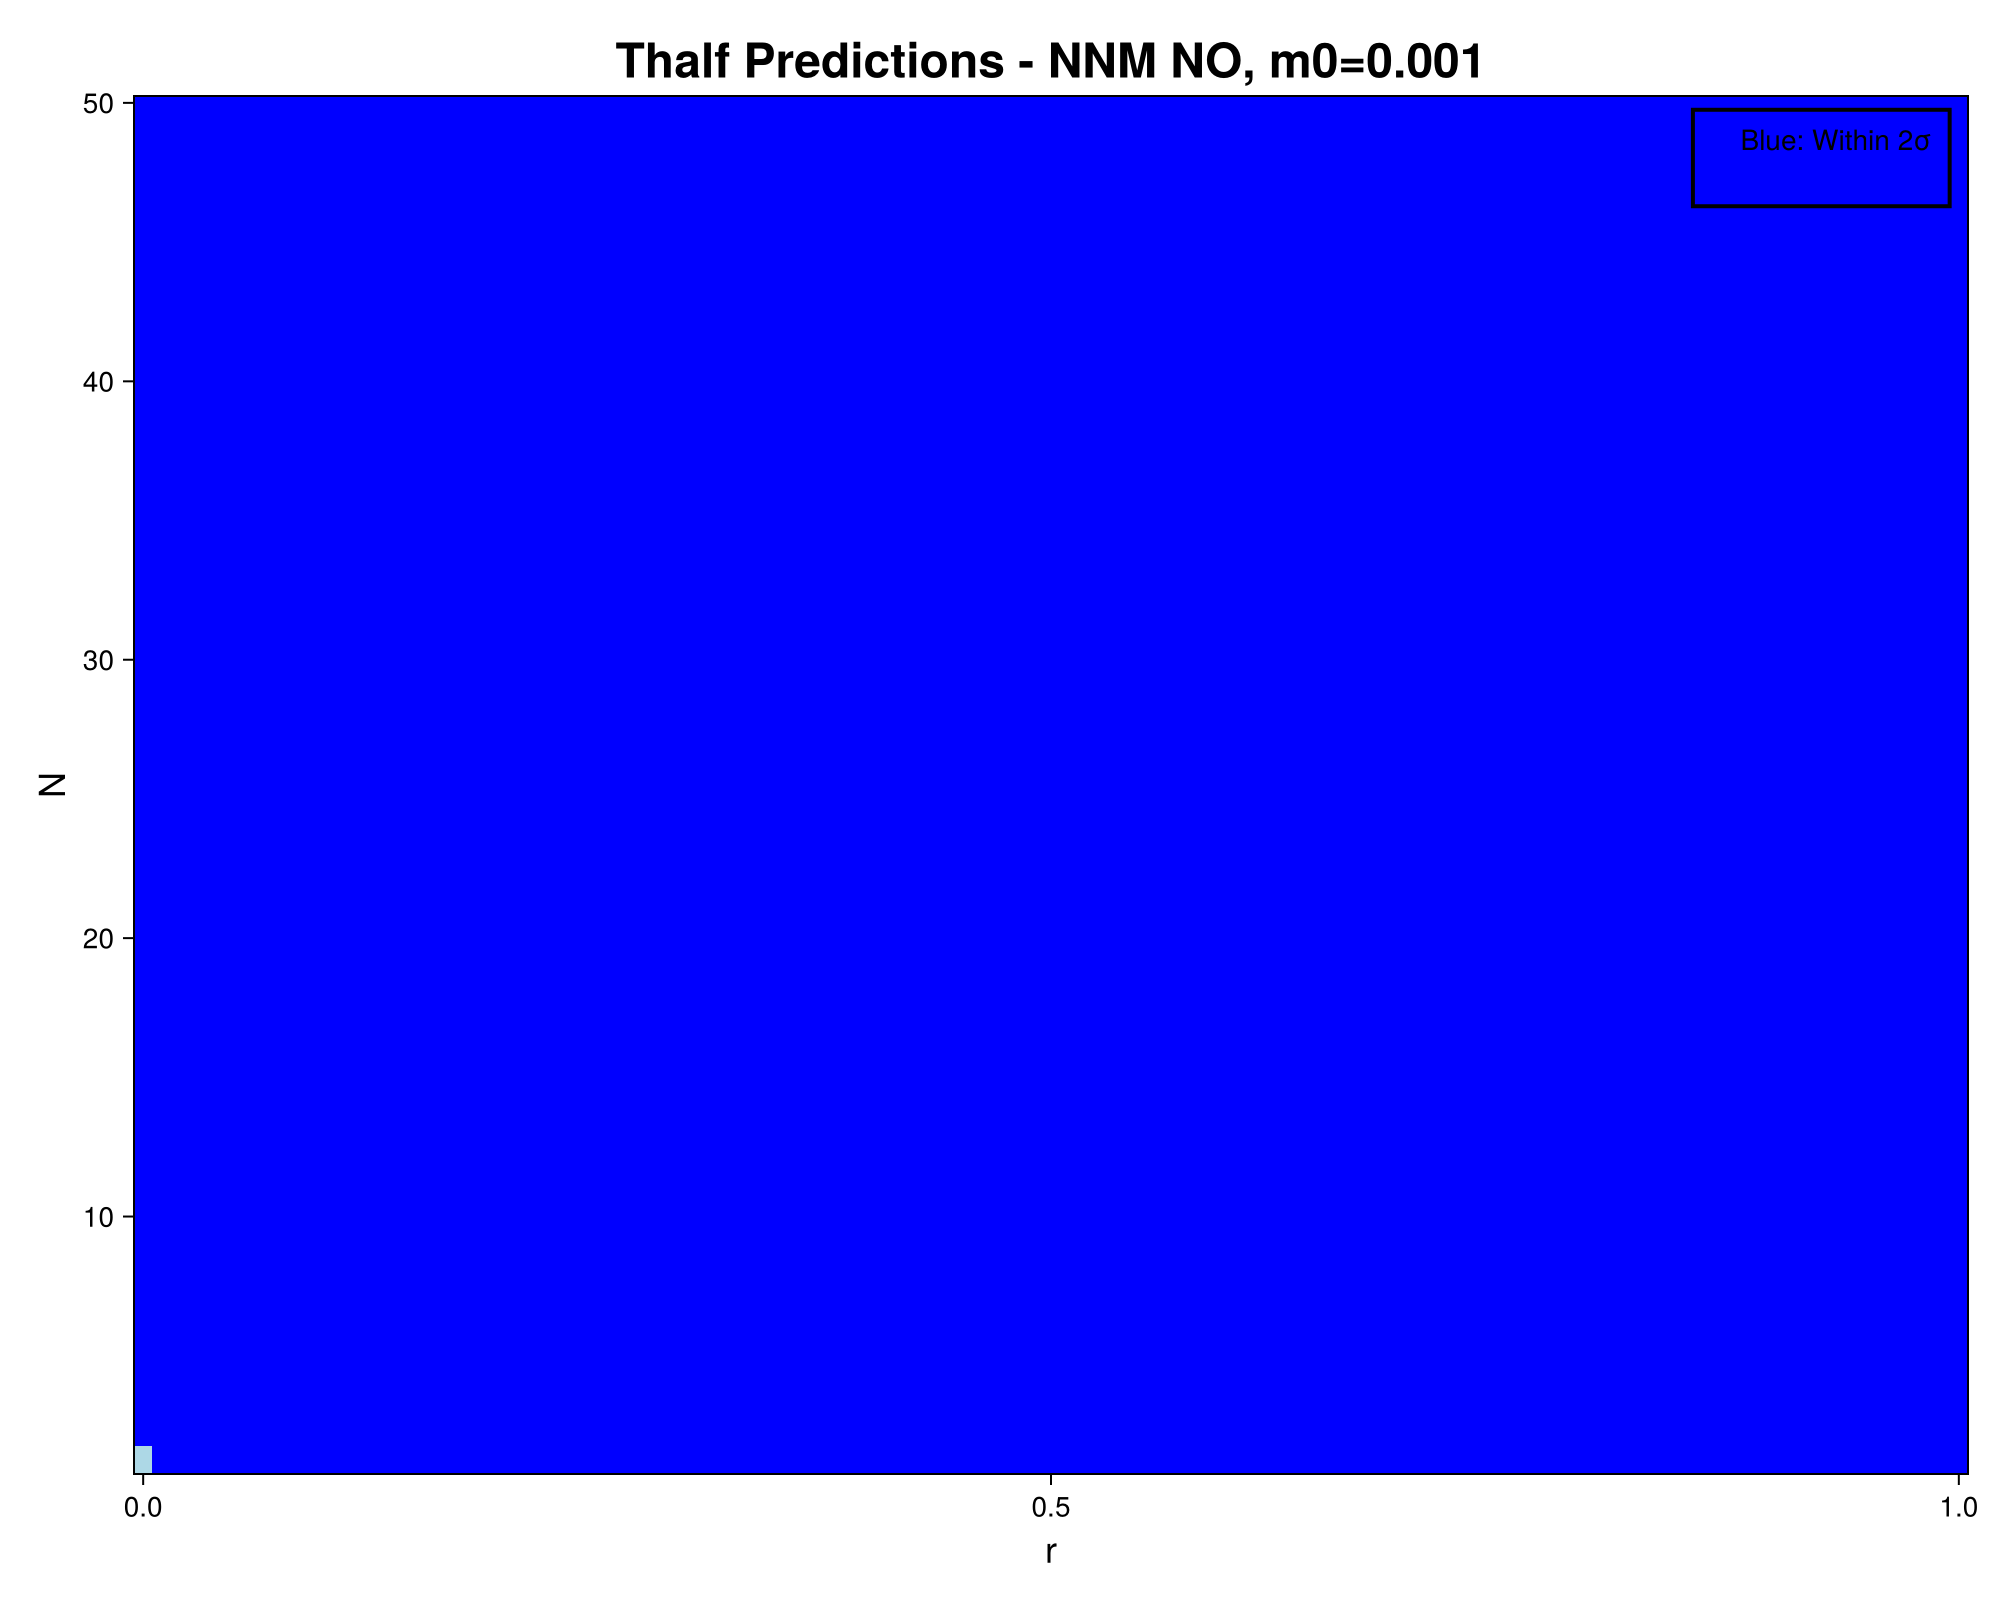

CairoMakie.Screen{IMAGE}


In [ ]:
using CairoMakie

# Get the actual lengths
n_r = length(r_range)
n_N = length(N_range)



# Reshape predicted values into 2D array
predicted_2d = reshape(predicted_N, n_r, n_N)

lower_bound = observed_mean - 2 * observed_sigma
upper_bound = observed_mean + 2* observed_sigma

within_2sigma = (predicted_2d .>= lower_bound) #.& (predicted_2d .<= upper_bound)
# Convert boolean matrix to numeric (1 for within, 0 for outside)
within_numeric = Float64.(within_2sigma)

# Create the plot with heatmap
fig1 = Figure(size=(1000, 800))
ax1 = Axis(fig1[1, 1],
    ylabel="N", 
    xlabel="r",
    title="Thalf Predictions - NNM NO, m0=0.001",
    titlesize=24,
    xlabelsize=18,
    ylabelsize=18)

# Use heatmap with blue/green colormap
heatmap!(ax1, r_range, N_range, within_numeric,
    colormap=[:lightblue, :blue])

# Add legend box with text
text!(ax1, 0.98, 0.98, 
    text="Blue: Within 2σ",
    space=:relative, fontsize=14, align=(:right, :top),
    color=:black)

# Draw a box around the legend using lines
lines!(ax1, [0.85, 0.99, 0.99, 0.85, 0.85], [0.92, 0.92, 0.99, 0.99, 0.92],
    space=:relative, color=:black, linewidth=2)

#save("/home/sofialon/Newtrinos.jl/plot_final/scans/gerda/Thalf_NNM_NO_rN_m0=0.001.png", fig1)
display(fig1)